In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [3]:
raw_data_root = "./kits23/dataset" 
# 病例 ID
case_id = "case_00000" 

In [7]:
def check_raw_kits_data():
    # 1. 組合原始路徑 (這是跟之前不一樣的地方)
    # 原始結構： root / case_id / imaging.nii.gz
    image_path = os.path.join(raw_data_root, case_id, "imaging.nii.gz")
    label_path = os.path.join(raw_data_root, case_id, "segmentation.nii.gz")

    print(f"📂 嘗試讀取病例: {case_id}")
    print(f"   - 影像路徑: {image_path}")
    print(f"   - 標籤路徑: {label_path}")

    # 2. 載入檔案
    img_obj = nib.load(image_path)
    lbl_obj = nib.load(label_path)

    # 獲取數據 (變成 numpy 陣列)
    img_data = img_obj.get_fdata()
    lbl_data = lbl_obj.get_fdata()

    # 3. 打印基本資訊
    print(f"\n✅ 讀取成功！")
    print(f"   - 形狀 (Shape): {img_data.shape} (寬, 高, 切片數)")
    
    # 4. 分析標籤內容
    unique_labels = np.unique(lbl_data)
    print(f"   - 標籤包含類別: {unique_labels}")
    # 根據 https://kits-challenge.org/kits23/ 類別的定義 0 for background, 1 for kidney, 2 for tumor, and 3 for cyst.
    labels_map = {0: "背景", 1: "腎臟", 2: "腫瘤", 3: "囊腫"}
    found_labels = [f"{int(x)}:{labels_map.get(int(x), '未知')}" for x in unique_labels]
    print(f"   - 檢測到的內容: {', '.join(found_labels)}")

    # 5. 視覺化 (找一張比較精彩的切片)
    # 這裡我們自動找包含「腫瘤(2)」的切片，如果沒有就找「腎臟(1)」，再沒有就取中間
    target_class = 2 if 2 in unique_labels else 1
    
    # 找出所有包含該類別的切片索引 (Z軸)
    slice_indices = np.where(lbl_data == target_class)[2]
    
    if len(slice_indices) > 0:
        # 選中間那張
        slice_idx = slice_indices[len(slice_indices) // 2]
        print(f"\n📸 展示含有 '{labels_map[target_class]}' 的切片: 第 {slice_idx} 層")
    else:
        slice_idx = img_data.shape[2] // 2
        print(f"\n📸 無前景，展示中間切片: 第 {slice_idx} 層")

    # 6. 繪圖
    plt.figure(figsize=(10, 5))

    # 左圖：CT 原圖
    plt.subplot(1, 2, 1)
    plt.title(f"Raw CT (Slice {slice_idx})")
    # 旋轉90度是為了讓它看起來跟 ITK-SNAP 方向一致 (這是 matplotlib 顯示習慣問題)
    plt.imshow(np.rot90(img_data[:, :, slice_idx]), cmap="gray", vmin=-150, vmax=250)
    plt.axis("off")

    # 右圖：標籤
    plt.subplot(1, 2, 2)
    plt.title(f"Segmentation (Slice {slice_idx})")
    plt.imshow(np.rot90(lbl_data[:, :, slice_idx]), cmap="jet", interpolation="nearest")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

關於 kits23.json 中 `case_00000` 這位病人的 **臨床數據 (Clinical Data)**。

如果是純粹做「影像分割 (Segmentation)」，這份檔案用處不大；但如果你要做「生存預測 (Survival Prediction)」或「腫瘤分級分類」，這份檔案非常關鍵。

以下幫你翻譯並解析這位 `case_00000` 病人的具體狀況：

### 1. 病人基本資料 (Demographics)
* **性別**: 男性 (`male`)
* **年齡**: 49 歲 (`age_at_nephrectomy`)
* **體型**: BMI 29.47 (體重過重，接近肥胖)
* **生活習慣**: 不吸菸 (`never_smoked`)，輕度飲酒。
* **身體狀況**: **非常健康**。他在 `comorbidities` (共病症) 這一欄全部都是 `false`，代表沒有高血壓、糖尿病、心臟病等常見慢性病。

### 2. 手術細節 (Surgery Info)
這部分描述了醫生如何切除腫瘤，對應到你在 ITK-SNAP 看到的影像：
* **手術方式**: 機器人輔助 (`robotic`) 的 **部分腎切除術** (`partial_nephrectomy`)。
    * *重點*：這解釋了為什麼你在影像中看到的是「一顆腎臟長著一顆瘤」，而不是整顆腎臟被拿掉。
* **手術時間**: 324 分鐘 (約 5.5 小時)。
* **缺血時間 (Ischemia time)**: 20 分鐘。
    * *解釋*：切除腫瘤時阻斷腎臟血流的時間。20 分鐘算控制得不錯，對腎功能影響較小。
* **出血量**: 400 cc。

### 3. 腫瘤病理報告 (Pathology - 最關鍵的部分)
這是切下來的腫瘤拿去化驗後的結果：
* **良惡性**: **惡性** (`malignant: true`)，也就是癌症。
* **腫瘤類型**: **透明細胞腎細胞癌** (`clear_cell_rcc`)。
    * 這是腎臟癌中最常見的一種類型。
* **腫瘤大小**:
    * 影像上看起來 (Radiographic): 2.4 cm
    * 實際切下來量 (Pathologic): 2.1 cm
* **癌症分期 (Stage)**: **T1a N0 M0**
    * `T1a`: 腫瘤小於 4cm 且侷限在腎臟內 (早期)。
    * `N0`: 沒有淋巴結轉移。
    * `M0`: 沒有遠端轉移。
* **惡性分級 (Grade)**: **ISUP Grade 3**。
    * 雖然是早期 (T1a)，但細胞長相比較兇猛 (Grade 3)，屬於高分化不良。

### 4. 預後與追蹤 (Outcome)
* **存活狀態**: `censored` (截尾/設限)。
    * *解釋*：這不是指資料被審查屏蔽，而是統計學術語。意思是直到最後一次追蹤（術後 1958 天，約 5.3 年），這位病人**還活著**，之後就沒有資料了（可能研究結束或病人失聯）。
* **腎功能 (eGFR)**:
    * 術前: 77
    * 術後半年: 76
    * 術後 5 年: 83
    * *結論*：手術非常成功，病人剩下的腎臟功能甚至比開刀前還好一點點。

---

### 這一份資料對 AI 訓練有什麼用？

如果你只是跑 Medical-SAM-Adapter 做**分割 (Segmentation)**：
* 這份 JSON **完全沒用**，你可以忽略它。你只需要 `.nii.gz` 影像。

如果你要進階做**預後分析 (Prognosis)**：
* 你可以訓練一個模型，輸入是 CT 影像，輸出是「預測這個腫瘤是良性還是惡性？」。
* 這時候 `malignant: true` 和 `tumor_histologic_subtype` 就是你的 **Ground Truth (標籤)**。

**簡單總結 `case_00000` 的故事**：
這是一位 49 歲的健康男性，發現了一顆 2.4 公分的早期腎臟癌。醫生用機器人幫他切除了腫瘤（保留了腎臟）。雖然腫瘤細胞有點兇猛 (Grade 3)，但因為發現得早且手術成功，他在術後 5 年依然活得很好，腎功能也正常。

📂 嘗試讀取病例: case_00000
   - 影像路徑: ./kits23/dataset/case_00000/imaging.nii.gz
   - 標籤路徑: ./kits23/dataset/case_00000/segmentation.nii.gz

✅ 讀取成功！
   - 形狀 (Shape): (611, 512, 512) (寬, 高, 切片數)
   - 標籤包含類別: [0. 1. 2.]
   - 檢測到的內容: 0:背景, 1:腎臟, 2:腫瘤

📸 展示含有 '腫瘤' 的切片: 第 182 層


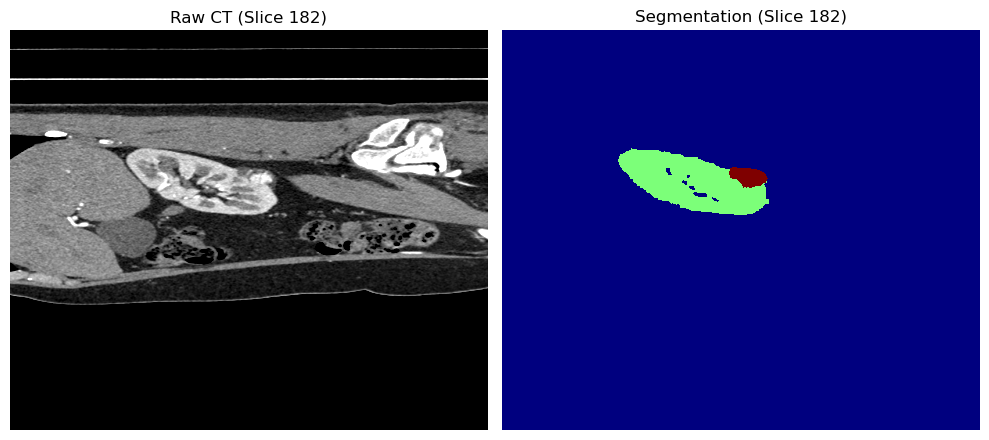

In [8]:
check_raw_kits_data()